# Regression Task: Beijing PM2.5 Prediction

**Dataset:** Beijing PM2.5 Data  
**Source:** UCI Machine Learning Repository  
**Target Variable:** `pm2.5`, renamed as `pm25` in the notebook  
**Task Type:** Regression





## Task 1: Exploratory Data Analysis and Data Understanding

## Task 1.1: Choosing a Dataset

For this regression task, I selected the **Beijing PM2.5 Data** dataset from the **UCI Machine Learning Repository**.

The dataset was created by **Song Chen** and donated to the UCI Machine Learning Repository on **18 January 2017**. The related research paper was published in 2015. The dataset contains hourly data from **1 January 2010 to 31 December 2014**.

I accessed the dataset from the UCI Machine Learning Repository:
https://archive.ics.uci.edu/dataset/381/beijing+pm2+5+data

The dataset contains PM2.5 air pollution measurements from the **US Embassy in Beijing** and weather data from **Beijing Capital International Airport**.

### UNSDG Alignment

This dataset mainly aligns with **UNSDG 3: Good Health and Well-being**, because PM2.5 pollution can affect human health, especially respiratory and cardiovascular health.

It also relates to **UNSDG 11: Sustainable Cities and Communities**, because monitoring and understanding air pollution supports cleaner and safer urban environments.

### Attribute Description

| Column | Description |
|---|---|
| No | Row number or record ID |
| year | Year of observation |
| month | Month of observation |
| day | Day of observation |
| hour | Hour of observation |
| pm2.5 | PM2.5 concentration in micrograms per cubic meter; target variable |
| DEWP | Dew point temperature in degrees Celsius |
| TEMP | Temperature in degrees Celsius |
| PRES | Atmospheric pressure in hPa |
| cbwd | Combined wind direction |
| Iws | Cumulated wind speed in m/s |
| Is | Cumulated hours of snow |
| Ir | Cumulated hours of rain |

### Potential Questions

1. Can PM2.5 concentration be predicted using weather and time-related variables?
2. Which weather variables are most related to PM2.5 concentration?
3. How does PM2.5 concentration change by year, month, hour, and wind direction?

### Dataset Suitability

The dataset is suitable for regression because the target variable, PM2.5 concentration, is continuous numerical data. It also has a large number of hourly records, which is useful for training and testing machine learning models.

However, the dataset is not perfect. The PM2.5 column has missing values, so cleaning is required. The dataset also contains extreme PM2.5 values, which need to be checked because they may affect model performance. Overall, the dataset is relevant, large enough, and appropriate for predicting air pollution levels.

In [238]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.feature_selection import RFE

In [239]:
from google.colab import files
uploaded = files.upload()

Saving PRSA_data_2010.1.1-2014.12.31.csv to PRSA_data_2010.1.1-2014.12.31 (4).csv


In [240]:
file_name = "PRSA_data_2010.1.1-2014.12.31.csv"

In [241]:
df = pd.read_csv(file_name)
df.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


#Exploratory Data Analysis (EDA):

Initial Data Inspection

In [242]:
df.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


In [243]:
df.shape

(43824, 13)

In [244]:
df.columns


Index(['No', 'year', 'month', 'day', 'hour', 'pm2.5', 'DEWP', 'TEMP', 'PRES',
       'cbwd', 'Iws', 'Is', 'Ir'],
      dtype='object')

In [245]:
df.dtypes

,0
No,int64
year,int64
month,int64
day,int64
hour,int64
pm2.5,float64
DEWP,int64
TEMP,float64
PRES,float64
cbwd,object


In [246]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  object 
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.3+ MB


In [247]:
df = df.rename(columns= {"pm2.5" : "pm25"})
df.columns

Index(['No', 'year', 'month', 'day', 'hour', 'pm25', 'DEWP', 'TEMP', 'PRES',
       'cbwd', 'Iws', 'Is', 'Ir'],
      dtype='object')

I first inspect the shape, columns, data types, and a few rows. This confirms that the CSV has loaded correctly and helps identify basic cleaning steps before modelling.

#Data Cleaning

In [248]:
df.isnull().sum()


,0
No,0
year,0
month,0
day,0
hour,0
pm25,2067
DEWP,0
TEMP,0
PRES,0
cbwd,0


In [249]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

No       0.000000
year     0.000000
month    0.000000
day      0.000000
hour     0.000000
pm25     4.716594
DEWP     0.000000
TEMP     0.000000
PRES     0.000000
cbwd     0.000000
Iws      0.000000
Is       0.000000
Ir       0.000000
dtype: float64


Only pm25 has missing values. Since pm25 is the target variable, these rows cannot be used for supervised learning because the model would not know the correct answer during training or evaluation. I remove rows where the target is missing.

In [250]:
df_clean = df.dropna(subset=["pm25"]).copy()
print(df_clean.isnull().sum())

No       0
year     0
month    0
day      0
hour     0
pm25     0
DEWP     0
TEMP     0
PRES     0
cbwd     0
Iws      0
Is       0
Ir       0
dtype: int64


In [251]:
duplicate_count = df_clean.duplicated().sum()
print("number of duplicate rows :", duplicate_count)

number of duplicate rows : 0


In [252]:
# Removing duplicate rows if there are any

df_clean = df_clean.drop_duplicates()
print("Shape after cleaning:", df_clean.shape)

Shape after cleaning: (41757, 13)


In [253]:

df_clean["datetime"] = pd.to_datetime(df_clean[["year","month", "day" , "hour"]])
df_clean.head()

,No,year,month,day,hour,pm25,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir,datetime
24,25,2010,1,2,0,129.0,-16,-4.0,1020.0,SE,1.79,0,0,2010-01-02 00:00:00
25,26,2010,1,2,1,148.0,-15,-4.0,1020.0,SE,2.68,0,0,2010-01-02 01:00:00
26,27,2010,1,2,2,159.0,-11,-5.0,1021.0,SE,3.57,0,0,2010-01-02 02:00:00
27,28,2010,1,2,3,181.0,-7,-5.0,1022.0,SE,5.36,1,0,2010-01-02 03:00:00
28,29,2010,1,2,4,138.0,-7,-5.0,1022.0,SE,6.25,2,0,2010-01-02 04:00:00


In [296]:
# Creating season variable from month

df_clean["season"] = "Winter"

df_clean.loc[(df_clean["month"] >= 3) & (df_clean["month"] <= 5), "season"] = "Spring"
df_clean.loc[(df_clean["month"] >= 6) & (df_clean["month"] <= 8), "season"] = "Summer"
df_clean.loc[(df_clean["month"] >= 9) & (df_clean["month"] <= 11), "season"] = "Autumn"

df_clean.head()

,No,year,month,day,hour,pm25,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir,datetime,season
24,25,2010,1,2,0,129.0,-16,-4.0,1020.0,SE,1.79,0,0,2010-01-02 00:00:00,Winter
25,26,2010,1,2,1,148.0,-15,-4.0,1020.0,SE,2.68,0,0,2010-01-02 01:00:00,Winter
26,27,2010,1,2,2,159.0,-11,-5.0,1021.0,SE,3.57,0,0,2010-01-02 02:00:00,Winter
27,28,2010,1,2,3,181.0,-7,-5.0,1022.0,SE,5.36,1,0,2010-01-02 03:00:00,Winter
28,29,2010,1,2,4,138.0,-7,-5.0,1022.0,SE,6.25,2,0,2010-01-02 04:00:00,Winter


In [297]:
df_clean["season"].unique()

array(['Winter', 'Spring', 'Summer', 'Autumn'], dtype=object)

In [255]:
print("Start date:", df_clean["datetime"].min())
print("End date:", df_clean["datetime"].max())
print("Wind direction values:", df_clean["cbwd"].unique())
print("Season values:", df_clean["season"].unique())

Start date: 2010-01-02 00:00:00
End date: 2014-12-31 23:00:00
Wind direction values: ['SE' 'cv' 'NW' 'NE']
Season values: ['winter' 'spring' 'Summer' 'Autumn']


In [256]:
df_clean.describe()

,No,year,month,day,hour,pm25,DEWP,TEMP,PRES,Iws,Is,Ir,datetime
count,41757.000000,41757.000000,41757.000000,41757.000000,41757.000000,41757.000000,41757.000000,41757.000000,41757.000000,41757.000000,41757.000000,41757.000000,41757
mean,22279.380104,2012.042771,6.513758,15.685514,11.502311,98.613215,1.750174,12.401561,1016.442896,23.866747,0.055344,0.194866,2012-07-17 06:22:48.374164736
min,25.000000,2010.000000,1.000000,1.000000,0.000000,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000,2010-01-02 00:00:00
25%,11464.000000,2011.000000,4.000000,8.000000,5.000000,29.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000,2011-04-23 15:00:00
50%,22435.000000,2012.000000,7.000000,16.000000,12.000000,72.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000,2012-07-23 18:00:00
75%,33262.000000,2013.000000,10.000000,23.000000,18.000000,137.000000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000,2013-10-17 21:00:00
max,43824.000000,2014.000000,12.000000,31.000000,23.000000,994.000000,28.000000,42.000000,1046.000000,565.490000,27.000000,36.000000,2014-12-31 23:00:00
std,12658.168415,1.415311,3.454199,8.785539,6.924848,92.050387,14.433658,12.175215,10.300733,49.617495,0.778875,1.418165,NaN


The summary statistics provide the mean, median, standard deviation, minimum, maximum, and quartiles for the numerical variables. These values are useful for understanding scale, spread, and possible extreme observations before choosing models and preprocessing steps.

In [257]:
Q1 = df_clean["pm25"].quantile(0.25)
Q3 = df_clean["pm25"].quantile(0.75)
iqr = Q3 - Q1
lower_bound = Q1 - 1.5 * iqr
upper_bound = Q3 + 1.5 * iqr

In [258]:
outliers = df_clean[(df_clean["pm25"]<lower_bound) | (df_clean["pm25"]>upper_bound)]
print("lower bound:",lower_bound)
print("upper bound:",upper_bound)
print("number of pm25 outliers is :",outliers.shape[0])

lower bound: -133.0
upper bound: 299.0
number of pm25 outliers is : 1773


#Visualization

##1:Distribution of PM2.5

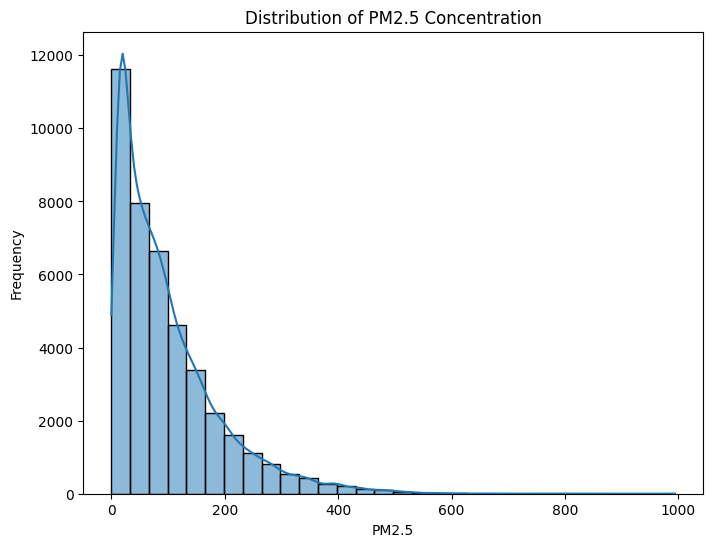

In [298]:
plt.figure(figsize=(8, 6))
sns.histplot(df_clean["pm25"], bins=30, kde=True)
plt.title("Distribution of PM2.5 Concentration")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")
plt.show()

The histogram shows that the PM2.5 data is positively right-skewed. Most of the PM2.5 values are low to moderate, while only a few values are very high. This creates a long tail on the right side, which means high pollution levels are less common.

##2: Boxplot of PM2.5

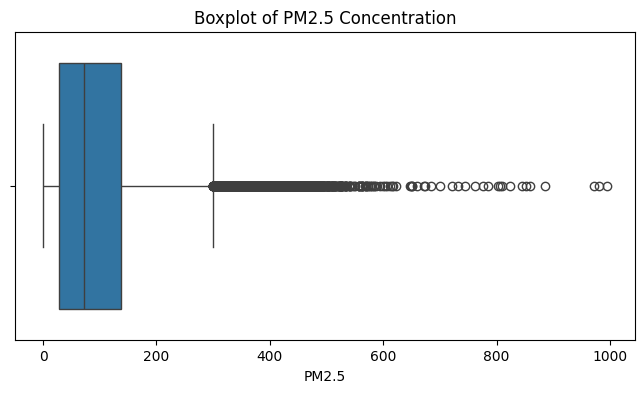

In [260]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean["pm25"])
plt.title("Boxplot of PM2.5 Concentration")
plt.xlabel("PM2.5")
plt.show()

The boxplot confirms that PM2.5 has high outlier values. These values shows serious pollution events.



#3: Correlation Heatmap

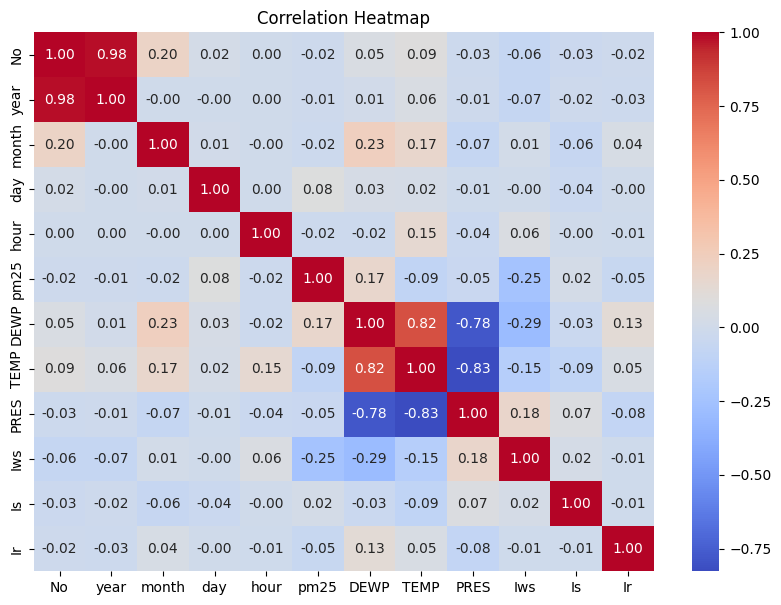

pm25     1.000000
DEWP     0.171423
day      0.082788
Is       0.019266
year    -0.014690
No      -0.017706
hour    -0.023116
month   -0.024069
PRES    -0.047282
Ir      -0.051369
TEMP    -0.090534
Iws     -0.247784
Name: pm25, dtype: float64


In [299]:
plt.figure(figsize=(10,7))
corr_matrix = df_clean.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

print(corr_matrix["pm25"].sort_values(ascending=False))

The correlation heatmap shows the linear relationships between the numerical variables. Most variables have weak correlation with PM2.5.

The strongest correlation with PM2.5 is `Iws` at about **-0.248**, showing that higher wind speed is linked with lower PM2.5 concentration. `DEWP` has a weak positive correlation with PM2.5 at about **0.171**, while `TEMP` has a weak negative correlation at about **-0.091**.

This means PM2.5 is not strongly explained by one single numerical feature. Instead, prediction may require a combination of weather and time-related variables.

### 4: PM2.5 vs Temperature



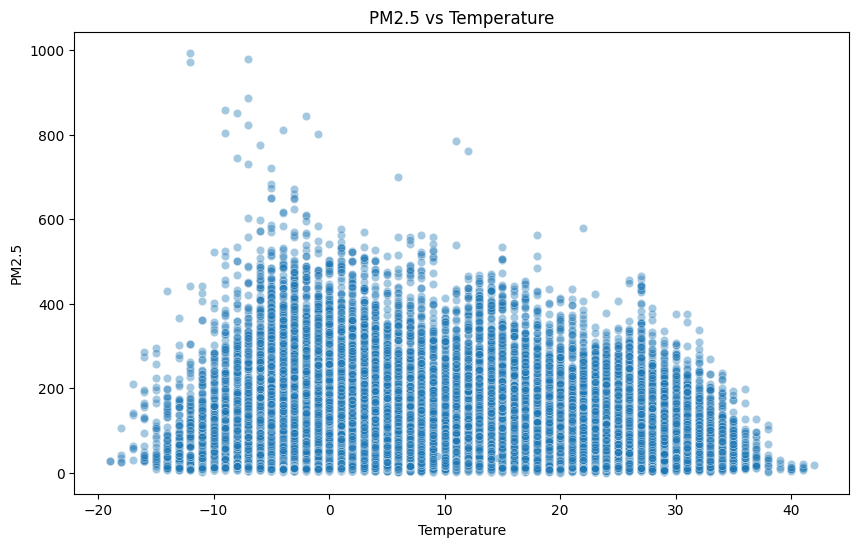

In [293]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="TEMP", y="pm25", data=df_clean, alpha=0.4)
plt.title("PM2.5 vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("PM2.5")
plt.show()

The scatter plot shows the relationship between Temperature and PM2.5 concentration. The points are widely scattered without a clear upward or downward trend, indicating a weak relationship between the two variables. Most observations have PM2.5 values below 400, while a few very high values appear as potential outliers.

##5: PM2.5 vs Wind Speed

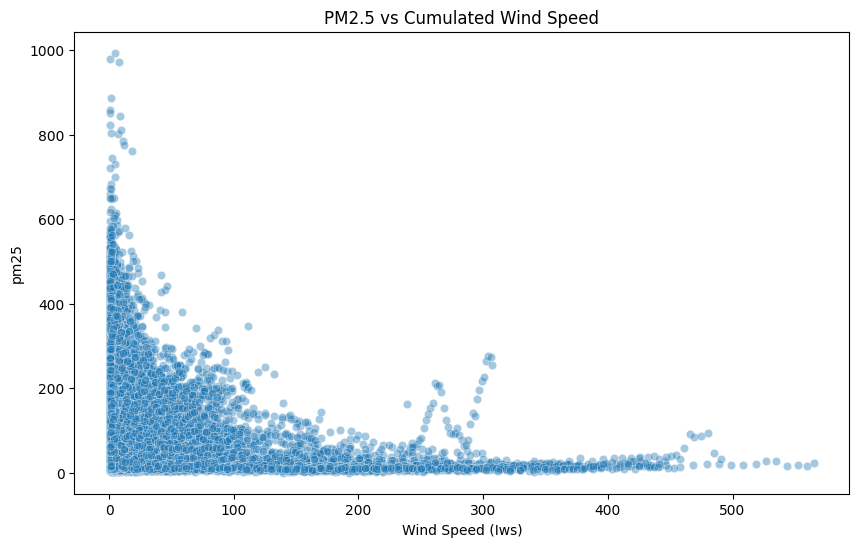

In [263]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Iws", y="pm25", data=df_clean , alpha=0.4)
plt.title("PM2.5 vs Cumulated Wind Speed")
plt.xlabel("Wind Speed (Iws)")
plt.show()

The scatter plot indicates a negative relationship between cumulated wind speed and PM2.5. Most high PM2.5 values occur at low wind speeds, while PM2.5 generally decreases as wind speed increases. A few outliers are also present.

##6: Average PM2.5 by Year

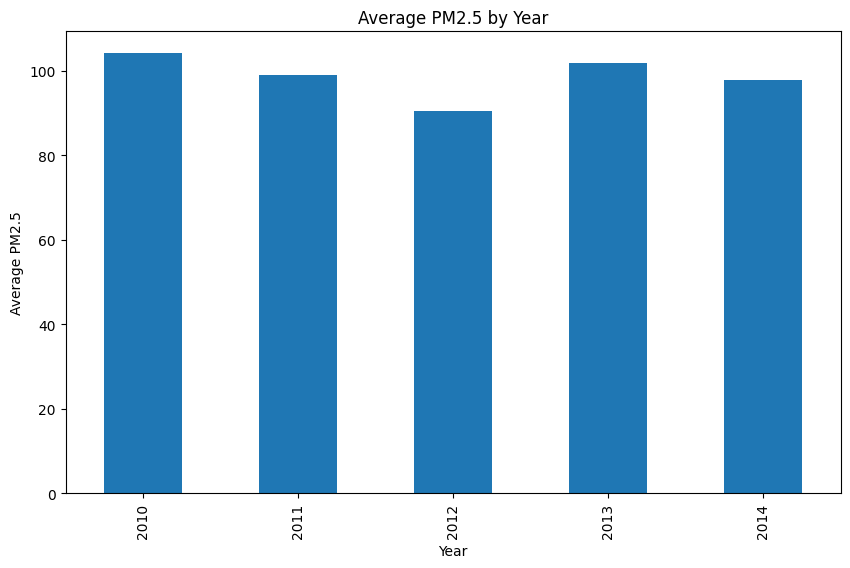

In [264]:
yearly_pm_25 = df_clean.groupby("year")["pm25"].mean()
plt.figure(figsize=(10, 6))
yearly_pm_25.plot(kind="bar")
plt.title("Average PM2.5 by Year")
plt.xlabel("Year")
plt.ylabel("Average PM2.5")
plt.show()

The bar chart shows the average PM2.5 concentration for each year from 2010 to 2014. The average PM2.5 was highest in 2010, decreased to its lowest level in 2012, increased again in 2013, and slightly decreased in 2014. Overall, the average PM2.5 varied across the years without showing a consistent increasing or decreasing trend.

##7: Average PM2.5 by Month

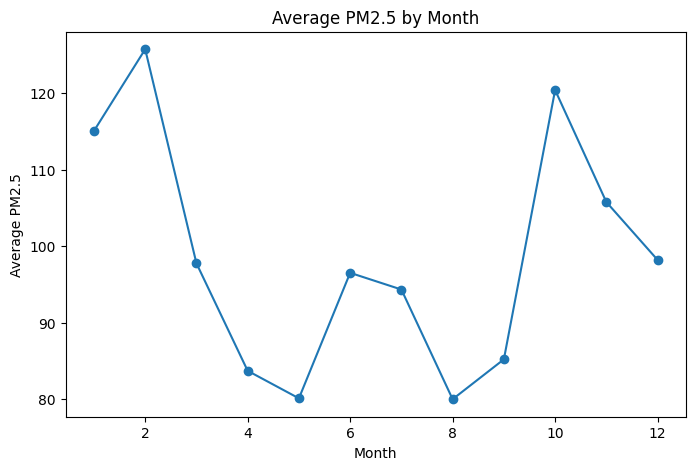

In [265]:
monthly_pm_25 = df_clean.groupby("month")["pm25"].mean()
plt.figure(figsize=(8, 5))
monthly_pm_25.plot(kind="line" , marker="o")
plt.title("Average PM2.5 by Month")
plt.xlabel("Month")
plt.ylabel("Average PM2.5")
plt.show()

The line chart shows average PM2.5 concentration for each month. The average PM2.5 is highest in February and October, while May and August have the lowest averages. Overall, PM2.5 levels fluctuate throughout the year without following a consistent increasing or decreasing trend.

##8: Average PM2.5 by Hour

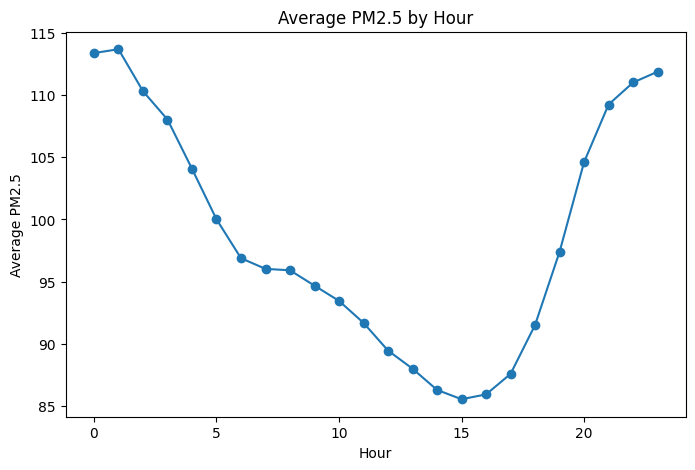

In [266]:
hourly_pm25 = df_clean.groupby("hour")["pm25"].mean()
plt.figure(figsize=(8, 5))
hourly_pm25.plot(kind="line", marker ="o")
plt.title("Average PM2.5 by Hour")
plt.xlabel("Hour")
plt.ylabel("Average PM2.5")
plt.show()

The line chart shows that the average PM2.5 level changes throughout the day. It is highest during the early morning and late evening, while the lowest average occurs in the afternoon.It shows pm2.5 of evry hour and it fluctuates and does not stay same.

## 9: Average PM2.5 by Wind Direction

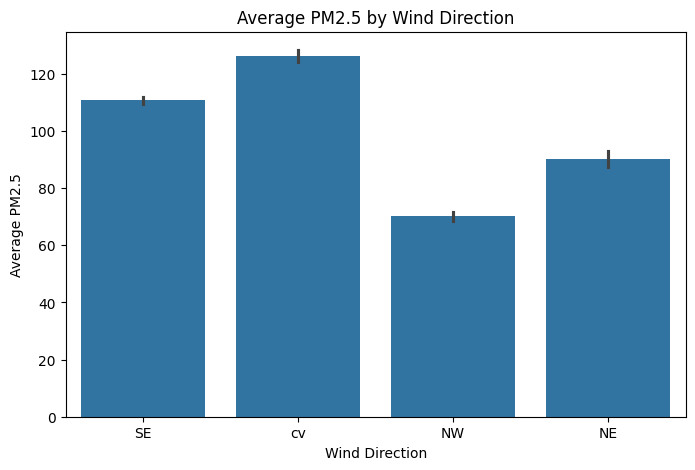

In [267]:
plt.figure(figsize=(8, 5))
sns.barplot(x="cbwd", y="pm25", data=df_clean)
plt.title("Average PM2.5 by Wind Direction")
plt.xlabel("Wind Direction")
plt.ylabel("Average PM2.5")
plt.show()

The bar chart shows that the average PM2.5 concentration varies by wind direction. The CV wind direction has the highest average PM2.5, while NW has the lowest.

#EDA Summary:

The dataset contains hourly air pollution and weather data. Missing target values were removed, and duplicate records were checked. PM2.5 has a right-skewed distribution with high outlier values, which were retained because they represent real pollution events. The analysis showed that PM2.5 varies across years, months, hours, and wind directions. Correlation analysis and scatter plots also indicated that several weather variables have relationships with PM2.5, suggesting that time and weather features may be useful for predicting PM2.5 concentration.

#Data Preparation for Machine Learning

Since machine learning models require numerical input, I prepared the dataset before training the neural network. I removed columns that were not useful for prediction, separated the target variable from the input features, converted categorical variables into dummy variables, split the data into training and testing sets, and scaled the features using StandardScaler.

In [268]:
#making copy of clean dataset for modelling
model_data = df_clean.copy()
#dropping columns that are not useful for prediction
model_data = model_data.drop(columns=["No","datetime"])
#converting categorical column into numerical dummy variables
model_data = pd.get_dummies(model_data, columns = ["cbwd" , "season"], drop_first=True , dtype=int)

model_data.head()

,year,month,day,hour,pm25,DEWP,TEMP,PRES,Iws,Is,Ir,cbwd_NW,cbwd_SE,cbwd_cv,season_Summer,season_spring,season_winter
24,2010,1,2,0,129.0,-16,-4.0,1020.0,1.79,0,0,0,1,0,0,0,1
25,2010,1,2,1,148.0,-15,-4.0,1020.0,2.68,0,0,0,1,0,0,0,1
26,2010,1,2,2,159.0,-11,-5.0,1021.0,3.57,0,0,0,1,0,0,0,1
27,2010,1,2,3,181.0,-7,-5.0,1022.0,5.36,1,0,0,1,0,0,0,1
28,2010,1,2,4,138.0,-7,-5.0,1022.0,6.25,2,0,0,1,0,0,0,1


In [269]:
# Separating input features and target variable

X = model_data.drop("pm25", axis=1)
y = model_data["pm25"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (41757, 16)
Target shape: (41757,)


In [270]:
X.head()

,year,month,day,hour,DEWP,TEMP,PRES,Iws,Is,Ir,cbwd_NW,cbwd_SE,cbwd_cv,season_Summer,season_spring,season_winter
24,2010,1,2,0,-16,-4.0,1020.0,1.79,0,0,0,1,0,0,0,1
25,2010,1,2,1,-15,-4.0,1020.0,2.68,0,0,0,1,0,0,0,1
26,2010,1,2,2,-11,-5.0,1021.0,3.57,0,0,0,1,0,0,0,1
27,2010,1,2,3,-7,-5.0,1022.0,5.36,1,0,0,1,0,0,0,1
28,2010,1,2,4,-7,-5.0,1022.0,6.25,2,0,0,1,0,0,0,1


In [271]:
# Spliting dataset into training and testing set 80 percent dat for lrearning or testing and 20 percent for test or predicting

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

Training feature shape: (33405, 16)
Testing feature shape: (8352, 16)


In [272]:
# Scaling  features for Linear Regression and Neural Network

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


The dataset was divided into 80% training data and 20% testing data. Then, StandardScaler was used to make the numerical features have a similar scale. The scaler learned the scaling information from the training data only and used the same information to scale the testing data. This helps many machine learning models, especially neural networks and linear models, learn more effectively and avoids data leakage.

#Task 2 Build a Neural Network Model for Regression

I used `MLPRegressor` from scikit-learn to build a neural network regression model.

The network architecture is:

- Input layer: 16 input features
- Hidden layer 1: 64 neurons
- Hidden layer 2: 32 neurons
- Activation function: ReLU
- Output layer: 1 continuous output value for predicted PM2.5
- Optimizer: Adam
- Loss function: Squared error loss

I also used `early_stopping=True`, which stops training when the model stops improving. This helps reduce overfitting. This model is suitable because PM2.5 prediction is a regression problem, and neural networks can learn nonlinear relationships between weather, time, and pollution variables.

# Training Neural Network Model

In [273]:
mlp_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=500,
    early_stopping=True,
    random_state=42
)

mlp_model.fit(X_train_scaled, y_train)

MLPRegressor(early_stopping=True, hidden_layer_sizes=(64, 32), max_iter=500,
             random_state=42)

#Evaluating Neural Network Model

In [274]:
mlp_train_predictions = mlp_model.predict(X_train_scaled)
mlp_test_predictions = mlp_model.predict(X_test_scaled)

print("Training MSE:", mean_squared_error(y_train, mlp_train_predictions))
print("Training RMSE:", np.sqrt(mean_squared_error(y_train, mlp_train_predictions)))
print("Training R2:", r2_score(y_train, mlp_train_predictions))

print("Testing MSE:", mean_squared_error(y_test, mlp_test_predictions))
print("Testing RMSE:", np.sqrt(mean_squared_error(y_test, mlp_test_predictions)))
print("Testing R2:", r2_score(y_test, mlp_test_predictions))

Training MSE: 2470.764217421143
Training RMSE: 49.70678240865267
Training R2: 0.705456424454203
Testing MSE: 2888.26132938575
Testing RMSE: 53.7425467333448
Testing R2: 0.6722173966726364


The neural network achieved a training R² of **0.705** and a testing R² of **0.672**. This means the model explains about 70.5% of the variation in the training data and about 67.2% of the variation in the testing data.

The testing RMSE is **53.74**, meaning the model predictions are typically about 54 PM2.5 units away from the actual values. The training and testing results are reasonably close, so the model does not show serious overfitting. However, the testing error is still quite high, which may be due to extreme PM2.5 pollution values and nonlinear patterns in the dataset.

## Task 3: Build Primary Machine Learning Models

For the classical machine learning models, I used:

1. Linear Regression
2. Random Forest Regressor

Linear Regression was used as a simple baseline model. Random Forest Regressor was used because it can capture nonlinear relationships between the input features and PM2.5 concentration.

For Linear Regression, I used the scaled training and testing data. For Random Forest, I used the original unscaled data because tree-based models do not require feature scaling.

In [275]:
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    return mse, rmse, mae, r2

Model - 1 Linear Regression

In [276]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

linear_mse, linear_rmse, linear_mae, linear_r2 = evaluate_model(
    linear_model, X_test_scaled, y_test
)

print("Linear Regression MSE:", linear_mse)
print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression MAE:", linear_mae)
print("Linear Regression R2:", linear_r2)

Linear Regression MSE: 6096.721880335806
Linear Regression RMSE: 78.08150792816316
Linear Regression MAE: 55.514905163489125
Linear Regression R2: 0.308096068258348


Model 2 - Random Forest Regressor

In [277]:
random_forest_model = RandomForestRegressor(
    n_estimators=50,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

rf_mse, rf_rmse, rf_mae, rf_r2 = evaluate_model(
    random_forest_model, X_test, y_test
)

print("Random Forest MSE:", rf_mse)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest MAE:", rf_mae)
print("Random Forest R2:", rf_r2)

Random Forest MSE: 1581.3196987547894
Random Forest RMSE: 39.765810676444026
Random Forest MAE: 23.69050287356322
Random Forest R2: 0.8205394081632769


Initial Model Comparison

In [278]:
initial_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "MSE": [linear_mse, rf_mse],
    "RMSE": [linear_rmse, rf_rmse],
    "MAE": [linear_mae, rf_mae],
    "R2 Score": [linear_r2, rf_r2]
})

initial_results.round(3)


,Model,MSE,RMSE,MAE,R2 Score
0,Linear Regression,6096.722,78.082,55.515,0.308
1,Random Forest Regressor,1581.320,39.766,23.691,0.821


The Random Forest Regressor performed much better than Linear Regression. It achieved a lower MSE, RMSE, and MAE, and a much higher R² score.

Linear Regression achieved an R² score of **0.308**, meaning it explained only about 30.8% of the variation in PM2.5 values. Random Forest achieved an R² score of **0.821**, meaning it explained about 82.1% of the variation in the test data.

Random Forest also had a much lower RMSE of **39.77**, compared with **78.08** for Linear Regression. This suggests that Random Forest is better for this dataset because the relationship between weather, time variables, and PM2.5 is likely nonlinear.

## Task 4: Hyperparameter Optimization with Cross-Validation

I used GridSearchCV to tune the hyperparameters of the two classical machine learning models from Task 3.

For Linear Regression, I tested:

- `fit_intercept`: whether the model should calculate an intercept value.

For Random Forest Regressor, I tested:

- `n_estimators`: the number of trees in the forest.
- `max_depth`: the maximum depth of each tree.
- `min_samples_split`: the minimum number of samples required to split a node.
- `min_samples_leaf`: the minimum number of samples required at a leaf node.

GridSearchCV tests different combinations of hyperparameter values and uses cross-validation to estimate model performance. I used R² as the scoring metric because this is a regression problem and R² shows how much variation in PM2.5 is explained by the model.

GridSearchCV for Linear Regression

In [279]:
linear_parameters = {
    "fit_intercept": [True, False]
}

linear_grid = GridSearchCV(
    LinearRegression(),
    linear_parameters,
    cv=5,
    scoring="r2"
)

linear_grid.fit(X_train_scaled, y_train)

print("Best Linear Regression Parameters:", linear_grid.best_params_)
print("Best Linear Regression CV Score:", linear_grid.best_score_)



Best Linear Regression Parameters: {'fit_intercept': True}
Best Linear Regression CV Score: 0.3143340909024531


GridSearchCV for Random Forest Regressor

In [280]:
rf_parameters = {
    "n_estimators": [50, 100],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_parameters,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:", rf_grid.best_params_)
print("Best Random Forest CV Score:", rf_grid.best_score_)

Best Random Forest Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Random Forest CV Score: 0.7966826608023041


In [281]:
tuning_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "Best Parameters": [linear_grid.best_params_, rf_grid.best_params_],
    "Best CV R2 Score": [linear_grid.best_score_, rf_grid.best_score_]
})

tuning_results
tuning_results.round(3)

,Model,Best Parameters,Best CV R2 Score
0,Linear Regression,{'fit_intercept': True},0.314
1,Random Forest Regressor,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.797


The best Linear Regression parameter was `fit_intercept=True`, with a cross-validation R² score of **0.314**. This shows that Linear Regression has limited predictive performance on this dataset.

The best Random Forest parameters were `max_depth=None`, `min_samples_leaf=1`, `min_samples_split=2`, and `n_estimators=100`, with a cross-validation R² score of **0.797**. This is much higher than the Linear Regression CV score.

Therefore, Random Forest performs better after cross-validation and is more suitable for this dataset. This is likely because Random Forest can capture nonlinear relationships between weather, time variables, and PM2.5 concentration.

## Feature Selection

I used Recursive Feature Elimination (RFE) for feature selection. RFE is a wrapper-based feature selection method. It works by training a model, ranking the features, removing the weakest features, and repeating this process until the required number of features remains.

I used RFE separately for Linear Regression and Random Forest because different models may find different features useful. Linear Regression selects features based on linear relationships, while Random Forest can capture nonlinear relationships and interactions between features.

I selected the top 10 features to reduce the number of input variables while still keeping enough information for prediction. This can make the final models simpler and easier to interpret.

RFE for Linear Regression

In [282]:
# Feature selection for Linear Regression using RFE

linear_rfe = RFE(
    estimator=LinearRegression(),
    n_features_to_select=10
)

linear_rfe.fit(X_train_scaled, y_train)

linear_selected_features = X_train.columns[linear_rfe.support_]

print("Selected features for Linear Regression:")
print(linear_selected_features)

Selected features for Linear Regression:
Index(['hour', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Ir', 'cbwd_SE', 'cbwd_cv',
       'season_Summer', 'season_winter'],
      dtype='object')


In [283]:
linear_feature_ranking = pd.DataFrame({
    "Feature": X_train.columns,
    "Selected": linear_rfe.support_,
    "Ranking": linear_rfe.ranking_
})

linear_feature_ranking.sort_values("Ranking")

,Feature,Selected,Ranking
3,hour,True,1
6,PRES,True,1
5,TEMP,True,1
4,DEWP,True,1
7,Iws,True,1
13,season_Summer,True,1
11,cbwd_SE,True,1
9,Ir,True,1
15,season_winter,True,1
12,cbwd_cv,True,1


RFE for Random Forest

In [284]:
# Feature selection for Random Forest using RFE

rf_rfe = RFE(
    estimator=RandomForestRegressor(n_estimators=50, random_state=42),
    n_features_to_select=10
)

rf_rfe.fit(X_train, y_train)

rf_selected_features = X_train.columns[rf_rfe.support_]

print("Selected features for Random Forest:")
print(rf_selected_features)

Selected features for Random Forest:
Index(['year', 'month', 'day', 'hour', 'DEWP', 'TEMP', 'PRES', 'Iws',
       'cbwd_SE', 'season_winter'],
      dtype='object')


In [285]:
rf_feature_ranking = pd.DataFrame({
    "Feature": X_train.columns,
    "Selected": rf_rfe.support_,
    "Ranking": rf_rfe.ranking_
})

rf_feature_ranking.sort_values("Ranking")

,Feature,Selected,Ranking
0,year,True,1
1,month,True,1
2,day,True,1
3,hour,True,1
4,DEWP,True,1
5,TEMP,True,1
6,PRES,True,1
7,Iws,True,1
11,cbwd_SE,True,1
15,season_winter,True,1


In [286]:
# Selected data for Linear Regression

X_train_linear_selected = X_train[linear_selected_features]
X_test_linear_selected = X_test[linear_selected_features]

# Selected data for Random Forest

X_train_rf_selected = X_train[rf_selected_features]
X_test_rf_selected = X_test[rf_selected_features]

In [287]:
# Scale selected features for Linear Regression

linear_selected_scaler = StandardScaler()

X_train_linear_selected_scaled = linear_selected_scaler.fit_transform(X_train_linear_selected)
X_test_linear_selected_scaled = linear_selected_scaler.transform(X_test_linear_selected)

In [288]:
print("Linear Regression selected training shape:", X_train_linear_selected.shape)
print("Linear Regression selected testing shape:", X_test_linear_selected.shape)

print("Random Forest selected training shape:", X_train_rf_selected.shape)
print("Random Forest selected testing shape:", X_test_rf_selected.shape)

Linear Regression selected training shape: (33405, 10)
Linear Regression selected testing shape: (8352, 10)
Random Forest selected training shape: (33405, 10)
Random Forest selected testing shape: (8352, 10)


RFE selected 10 features for each model. For Linear Regression, the selected features include weather variables such as `DEWP`, `TEMP`, `PRES`, `Iws`, and `Ir`, as well as time and categorical dummy variables. These features are useful because PM2.5 concentration can be affected by weather conditions, wind direction, and seasonal patterns.

For Random Forest, RFE selected time variables such as `year`, `month`, `day`, and `hour`, along with weather variables such as `DEWP`, `TEMP`, `PRES`, and `Iws`. This suggests that Random Forest uses both time-based patterns and weather-related variables to predict PM2.5.

The selected features are not exactly the same for both models because Linear Regression and Random Forest learn relationships differently. These selected feature sets will be used in the final model building step.

#Task 6: Final Models and Comparative Analysis

Final Linear Regression Model

In [289]:
# Final Linear Regression model using best hyperparameter and selected features
final_linear_model = LinearRegression(
    fit_intercept=linear_grid.best_params_["fit_intercept"]
)

final_linear_model.fit(X_train_linear_selected_scaled, y_train)

final_linear_mse, final_linear_rmse, final_linear_mae, final_linear_r2 = evaluate_model(
    final_linear_model,
    X_test_linear_selected_scaled,
    y_test
)

print("Final Linear Regression MSE:", final_linear_mse)
print("Final Linear Regression RMSE:", final_linear_rmse)
print("Final Linear Regression MAE:", final_linear_mae)
print("Final Linear Regression R2:", final_linear_r2)

Final Linear Regression MSE: 6166.231436635216
Final Linear Regression RMSE: 78.52535537414151
Final Linear Regression MAE: 55.742727274872
Final Linear Regression R2: 0.3002075773215547


Final Random Forest Model

In [290]:
final_rf_model = RandomForestRegressor(
    n_estimators=rf_grid.best_params_["n_estimators"],
    max_depth=rf_grid.best_params_["max_depth"],
    min_samples_split=rf_grid.best_params_["min_samples_split"],
    min_samples_leaf=rf_grid.best_params_["min_samples_leaf"],
    random_state=42
)

final_rf_model.fit(X_train_rf_selected, y_train)

final_rf_mse, final_rf_rmse, final_rf_mae, final_rf_r2 = evaluate_model(
    final_rf_model,
    X_test_rf_selected,
    y_test
)

print("Final Random Forest MSE:", final_rf_mse)
print("Final Random Forest RMSE:", final_rf_rmse)
print("Final Random Forest MAE:", final_rf_mae)
print("Final Random Forest R2:", final_rf_r2)

Final Random Forest MSE: 1522.0895623323756
Final Random Forest RMSE: 39.01396624713227
Final Random Forest MAE: 23.29215756704981
Final Random Forest R2: 0.8272613097150671


Cross-Validation Scores

In [291]:
# Cross-validation score for final Linear Regression

final_linear_cv_scores = cross_val_score(
    final_linear_model,
    X_train_linear_selected_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

final_linear_cv_score = final_linear_cv_scores.mean()


# Cross-validation score for final Random Forest

final_rf_cv_scores = cross_val_score(
    final_rf_model,
    X_train_rf_selected,
    y_train,
    cv=3,
    scoring="r2"
)

final_rf_cv_score = final_rf_cv_scores.mean()

print("Final Linear Regression CV Score:", final_linear_cv_score)
print("Final Random Forest CV Score:", final_rf_cv_score)

Final Linear Regression CV Score: 0.3065420930749013
Final Random Forest CV Score: 0.7950220447940982


Final Comparison Table

In [292]:
# Final comparison table

final_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "Features Used": [len(linear_selected_features), len(rf_selected_features)],
    "CV Score": [final_linear_cv_score, final_rf_cv_score],
    "Test RMSE": [final_linear_rmse, final_rf_rmse],
    "Test R-squared": [final_linear_r2, final_rf_r2],
    "Test MSE": [final_linear_mse, final_rf_mse],
    "Test MAE": [final_linear_mae, final_rf_mae]
})

final_results.round(3)

,Model,Features Used,CV Score,Test RMSE,Test R-squared,Test MSE,Test MAE
0,Linear Regression,10,0.307,78.525,0.300,6166.231,55.743
1,Random Forest Regressor,10,0.795,39.014,0.827,1522.090,23.292


The final Random Forest Regressor performed better than the final Linear Regression model. It achieved a much lower test RMSE of **39.01**, compared with **78.53** for Linear Regression. It also achieved a higher test R² score of **0.827**, compared with **0.300** for Linear Regression.

The Random Forest model also had a higher cross-validation score of **0.795**, while Linear Regression had a CV score of **0.307**. This shows that Random Forest performed better not only on the test set but also during cross-validation.

Compared with the initial Random Forest model, the final Random Forest model improved slightly after hyperparameter tuning and feature selection. Therefore, the final Random Forest Regressor is the best model for predicting PM2.5 concentration in this assignment.